In [1]:
import pandas as pd
import importlib
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import edits_with_volume_plot as ewv
import tensorflow
import tensorflow_hub as hub
import numpy as np
_ = importlib.reload(ewv)

"""A shortcut for loading files from data directory"""
DR = "data/datasets/"

/Users/ruzhylopv/Desktop/Year 2/Econometrics/Proj/.venv3-13/lib/python3.13/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


## Brainstorming: 29.03


### 1. Motivating descriptive analysis: plotting wikipedia editing intensity vs. stock market volume at monthly snapshots
---

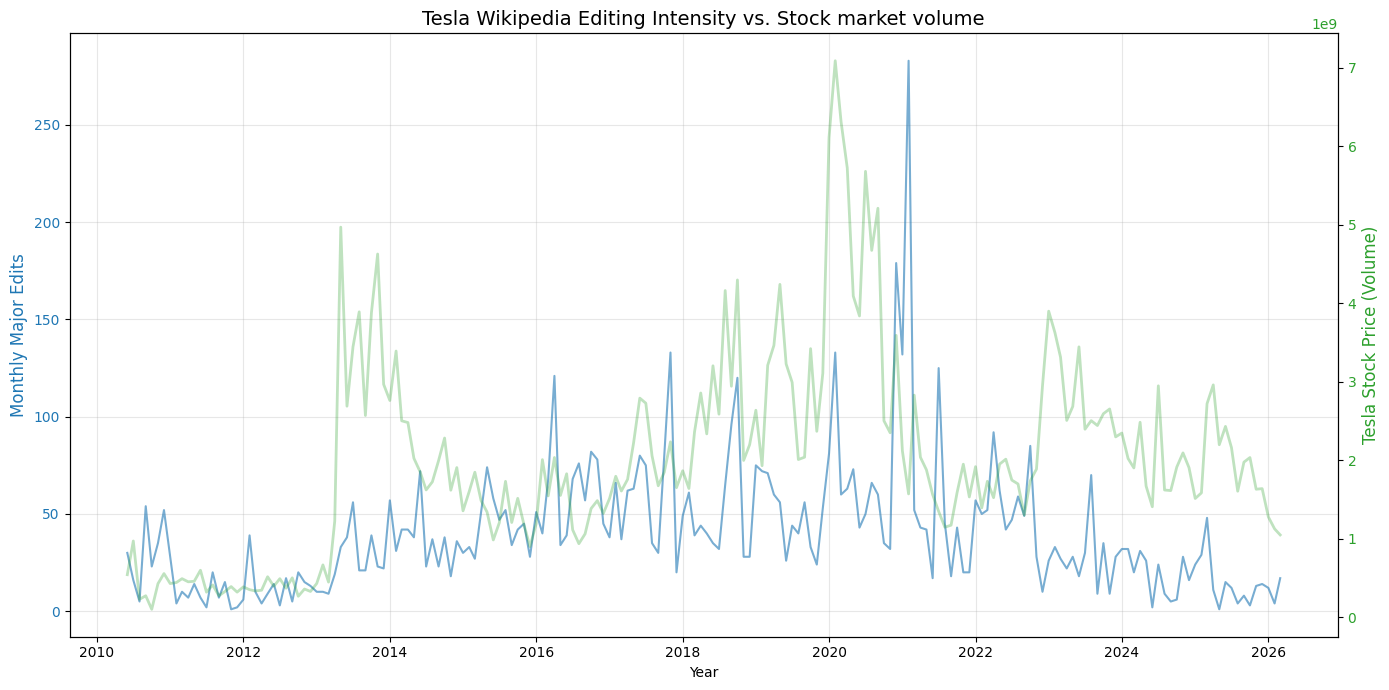

In [2]:
ewv.plot_edits_with_volume(f"{DR}WIKI_tesla.csv", f"{DR}STOCK_tesla.csv")

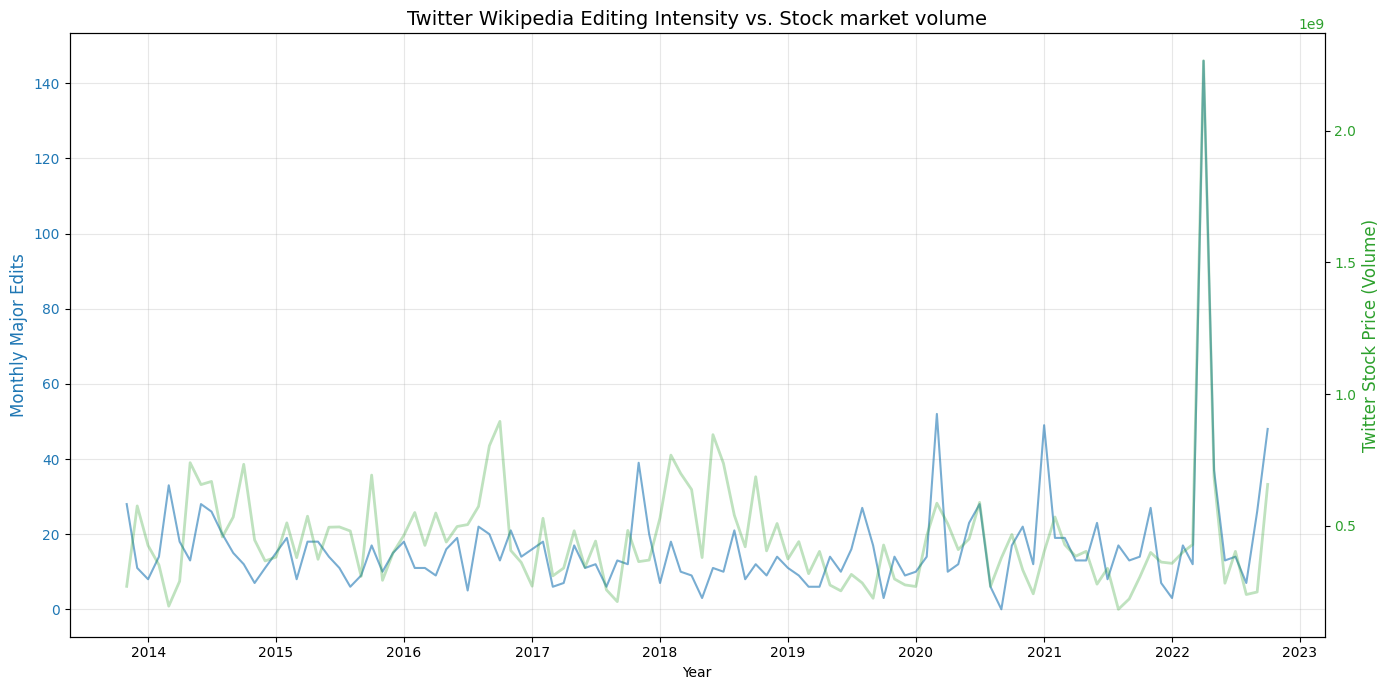

In [13]:
ewv.plot_edits_with_volume(f"{DR}WIKI_x_twitter.csv", f"{DR}STOCK_twitter.csv")

### 2. Data engineering: trying to derive semantic drift measure
---
High-level question: *Does Narrative Instability on Wikipedia serve as a Leading Indicator for Stock Market Volatility*

IDEAS:
- Enrichen the research by including more articles in the model


For the start, it is worth to consider different measures of text similarity to describe the data \
On input shall be a dataset with revisions, output shall be a time series plot

Then, it is worth plotting stock (for example, tesla) over the plots.

### Measures of similarity / Embedding methods:
- Levenstein distance (too naive)
- BoW embedding
- SpaCy averaging embedding, naive in a sense that it loses order
- TF-IDF
- Doc2Vec
- USE from google

In [4]:
df = ewv.prepare_wiki_df(pd.read_csv(f"{DR}WIKI_tesla.csv"))
monthly_snapshots = df.resample("MS").ffill()

df.head()

,Unnamed: 0,revid,parentid,user,temp,comment,size,sha1,flags,intro_text,minor
timestamp,,,,,,,,,,,
2026-03-04 15:40:55+00:00,14,1341702558,1341177817,ReferenceMan,False,NaN,350086,3d84ab4fb429edbd14af30644b62226d64dd42f4,NaN,"Tesla, Inc. is an American multinational auto...",False
2026-03-01 22:14:29+00:00,15,1341177817,1341059137,Dreamyshade,False,NaN,350085,60e2a89d720eaa7d1c4cc87455f828a38bb3668b,NaN,"Tesla, Inc. is an American multinational auto...",False
2026-03-01 04:59:02+00:00,17,1341057129,1341057110,Z1720,False,NaN,349849,77b50b937cb1cc89d027d8a6cec83b8775583276,NaN,"Tesla, Inc. is an American multinational auto...",False
2026-03-01 04:58:56+00:00,18,1341057110,1341057062,Z1720,False,NaN,349253,a4daa3101a3b37ac2ee9027ee0f25a12ed2d0105,NaN,"Tesla, Inc. is an American multinational auto...",False
2026-03-01 04:58:28+00:00,19,1341057062,1341057050,Z1720,False,NaN,349247,3c6ec8fe5660ab29617d77cb0e37d79800e85c54,NaN,"Tesla, Inc. is an American multinational auto...",False


In [4]:
module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
embed = hub.load(module_url)

In [53]:
sentences = monthly_snapshots["intro_text"].fillna("")

In [59]:
query = sentences.iloc[0]

sentence_embeddings = embed(sentences.tolist())
query_embedding = embed([query])



cosine_similarities = np.inner(query_embedding, sentence_embeddings)

In [60]:
monthly_snapshots["cos_baseline"] = cosine_similarities[0]

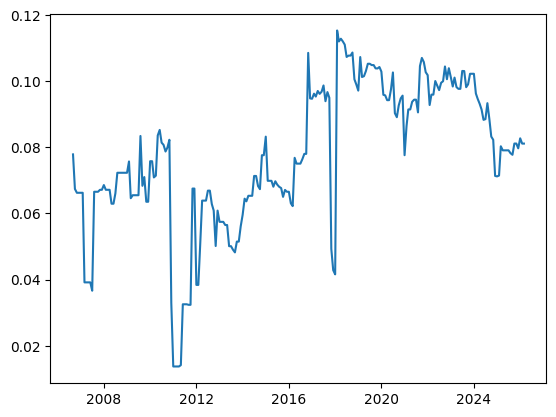

In [110]:
plt.plot(monthly_snapshots.cos_baseline.iloc[3:])

In [108]:
current = sentence_embeddings[1:]   # Shape: (237, 512)
previous = sentence_embeddings[:-1] # Shape: (237, 512)
mom_similarities = np.sum(current * previous, axis=1)
mom_similarities_full = np.insert(mom_similarities, 0, 0)
monthly_snapshots["mom_similarities_full"] = mom_similarities_full
monthly_snapshots["drift"] = 1 - mom_similarities_full
monthly_snapshots["narrative_uncertainty"] = monthly_snapshots["mom_similarities_full"].rolling(6).std().fillna(0)

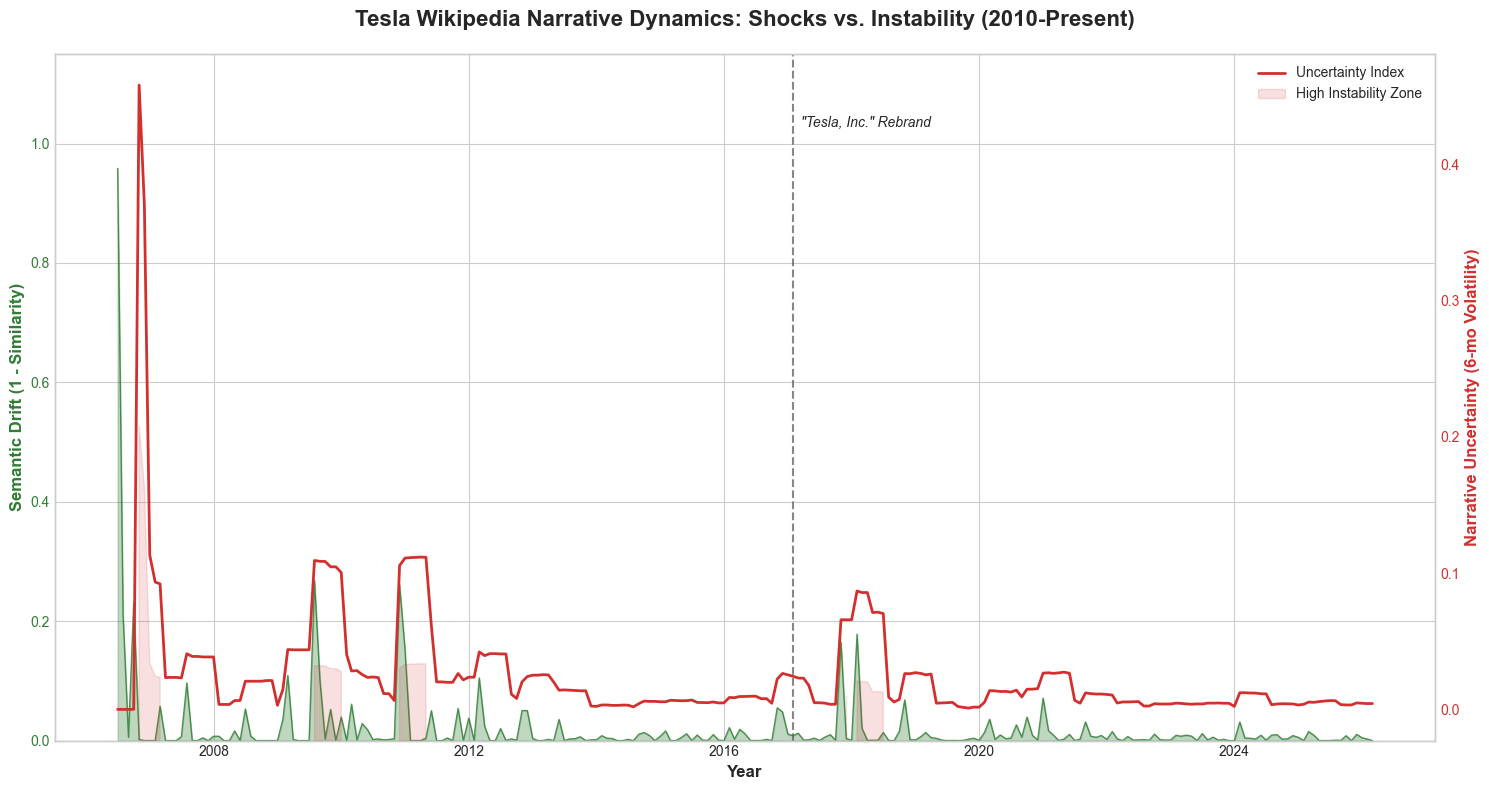

In [112]:


# 1. Clean the data for plotting
# We skip the first row because the '0' placeholder makes a fake spike of 1.0
plot_df = monthly_snapshots.iloc[1:].copy()

# 2. Setup the figure
fig, ax1 = plt.subplots(figsize=(15, 8), dpi=100)
plt.style.use('seaborn-v0_8-whitegrid') # Use a clean, modern style

# --- A. Plot Monthly Semantic Drift (The "Shocks") ---
# We use 'step' or 'fill_between' to make the pulses look like "energy"
color_drift = '#2e7d32' # A nice deep green
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Semantic Drift (1 - Similarity)', color=color_drift, fontsize=12, fontweight='bold')

# The 'fill_between' creates a pulse-like effect
ax1.fill_between(plot_df.index, plot_df["drift"], color=color_drift, alpha=0.3, label="Monthly Semantic Change")
ax1.plot(plot_df.index, plot_df["drift"], color=color_drift, linewidth=1, alpha=0.8)

ax1.tick_params(axis='y', labelcolor=color_drift)
ax1.set_ylim(0, plot_df["drift"].max() * 1.2) # Give some headroom

# --- B. Plot Narrative Uncertainty (The "Volatility") ---
# We use a second axis to show the rolling instability
ax2 = ax1.twinx()
color_unc = '#d32f2f' # A warning red
ax2.set_ylabel('Narrative Uncertainty (6-mo Volatility)', color=color_unc, fontsize=12, fontweight='bold')

# Plot the uncertainty as a smooth line
ax2.plot(plot_df.index, plot_df["narrative_uncertainty"], color=color_unc, linewidth=2, label="Uncertainty Index")

# BEAUTY STEP: Shade the background red when uncertainty is high (Top 10% of history)
threshold = plot_df["narrative_uncertainty"].quantile(0.90)
ax2.fill_between(plot_df.index, 0, plot_df["narrative_uncertainty"], 
                 where=(plot_df["narrative_uncertainty"] >= threshold),
                 color=color_unc, alpha=0.15, transform=ax2.get_xaxis_transform(), label="High Instability Zone")

ax2.tick_params(axis='y', labelcolor=color_unc)
ax2.grid(False) # Turn off the second grid to keep it clean

# --- C. Add Context (Tesla Name Change) ---
rebrand_date = pd.to_datetime('2017-02-01')
ax1.axvline(rebrand_date, color='#555555', linestyle='--', alpha=0.7)
ax1.text(rebrand_date, ax1.get_ylim()[1]*0.9, '  "Tesla, Inc." Rebrand', 
         fontsize=10, fontstyle='italic', verticalalignment='center')

# --- D. Final Touches ---
plt.title('Tesla Wikipedia Narrative Dynamics: Shocks vs. Instability (2010-Present)', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.legend()
# Save the plot
plt.savefig('tesla_semantic_pretty_plot.png')

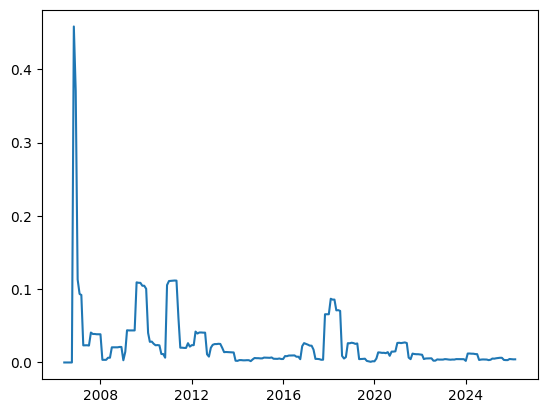

In [109]:
plt.plot(monthly_snapshots["narrative_uncertainty"])

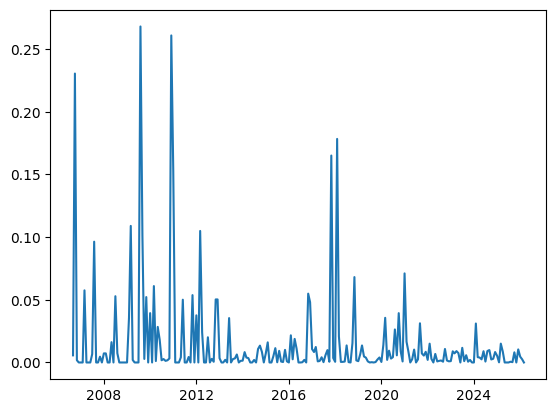

In [91]:
plt.plot(monthly_snapshots["drift"].iloc[3:])

Cumulative convergence to 1 | How articles become more and more like the current version through edit history

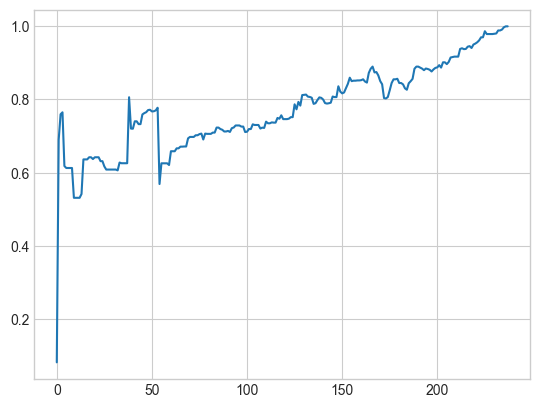

In [121]:

query = sentences.iloc[-1]
sentence_embeddings = embed(sentences.tolist())
query_embedding = embed([query])



cosine_similarities = np.inner(query_embedding, sentence_embeddings)[0]
plt.plot(cosine_similarities)

High-level question: *Does Narrative Instability on Wikipedia serve as a Leading Indicator for Stock Market Volatility*